# Probabilities

In [76]:
from pathlib import Path
import json
import re

import pandas as pd
from IPython.display import display


PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_ROOT = PROJECT_ROOT / "data" / "cut_images" / "split" / "test"

with open(PROJECT_ROOT / "data" / "mapping.json", "r", encoding="utf-8") as f:
    mapping = json.load(f)["id_to_name"]

# Keep the defined habitat names in a fixed order.
habitats = ["dense", "dense_leafless", "dense_snow", "open", "open_leafless", "open_snow", "sparse", "sparse_leafless", "sparse_snow"]
species_order = [mapping[key] for key in sorted(mapping)]

# Cutout filenames look like: flight_frame_g<cluster>_<count><species><count><species>...jpg
species_chunk_pattern = re.compile(r"(\d+)([a-l])", re.IGNORECASE)
filename_suffix_pattern = re.compile(r"_g\d+_(.+)$")

mc_dropout_results_path = PROJECT_ROOT / "notebooks" / "models" / "mc_dropout_results_efficientnetv2-s.csv"
habitat_mean_variance = pd.Series(dtype="float64")
habitat_uncertainty_weights = pd.Series(1.0, index=habitats, dtype="float64")
if mc_dropout_results_path.exists():
    mc_dropout_results = pd.read_csv(mc_dropout_results_path)
    variance_columns = [column for column in mc_dropout_results.columns if column.startswith("variance_T")]
    if variance_columns:
        habitat_mean_variance = (
            mc_dropout_results.assign(
                mean_variance=lambda frame: frame[variance_columns].mean(axis=1, skipna=True)
            )
            .groupby("true_label")["mean_variance"]
            .mean()
            .reindex(habitats)
        )
        habitat_uncertainty_weights = (1.0 / (1.0 + habitat_mean_variance)).fillna(1.0)

records: list[dict[str, object]] = []
skipped_files: list[Path] = []



In [77]:
for image_path in DATA_ROOT.rglob("*.jpg"):
    habitat = image_path.parent.name
    suffix_match = filename_suffix_pattern.search(image_path.stem)
    if habitat not in habitats or suffix_match is None:
        skipped_files.append(image_path)
        continue

    species_suffix = suffix_match.group(1)
    species_chunks = species_chunk_pattern.findall(species_suffix)
    if not species_chunks:
        skipped_files.append(image_path)
        continue

    for count_text, class_id in species_chunks:
        species_name = mapping[class_id.lower()]
        uncertainty_weight = float(habitat_uncertainty_weights.get(habitat, 1.0))
        records.append(
            {
                "habitat": habitat,
                "species": species_name,
                "count": int(count_text),
                "mean_variance": float(habitat_mean_variance.get(habitat, float("nan"))),
                "uncertainty_weight": uncertainty_weight,
                "weighted_count": int(count_text) * uncertainty_weight,
            }
        )
    


counts_df = pd.DataFrame(records)
if counts_df.empty:
    raise ValueError(f"No parseable cutout filenames found under {DATA_ROOT}")

joint_counts = counts_df.groupby(["habitat", "species"], as_index=False)[["count", "weighted_count"]].sum()

raw_joint_pivot = (
    joint_counts.pivot(index="habitat", columns="species", values="count")
    .reindex(index=habitats, columns=species_order)
    .fillna(0)
)

joint_pivot = (
    joint_counts.pivot(index="habitat", columns="species", values="weighted_count")
    .reindex(index=habitats, columns=species_order)
    .fillna(0)
)

merged_habitats = ["dense", "open", "sparse"]
merged_raw_joint_pivot = (
    raw_joint_pivot.assign(merged_habitat=[habitat.split("_")[0] for habitat in raw_joint_pivot.index])
    .groupby("merged_habitat")
    .sum()
    .reindex(index=merged_habitats, columns=species_order)
    .fillna(0)
)
merged_joint_pivot = (
    joint_pivot.assign(merged_habitat=[habitat.split("_")[0] for habitat in joint_pivot.index])
    .groupby("merged_habitat")
    .sum()
    .reindex(index=merged_habitats, columns=species_order)
    .fillna(0)
)

p_species_given_habitat_raw = merged_raw_joint_pivot.div(merged_raw_joint_pivot.sum(axis=1), axis=0).fillna(0)
p_habitat_given_species_raw = merged_raw_joint_pivot.T.div(merged_raw_joint_pivot.T.sum(axis=1), axis=0).fillna(0)

p_species_given_habitat = merged_joint_pivot.div(merged_joint_pivot.sum(axis=1), axis=0).fillna(0)
p_habitat_given_species = merged_joint_pivot.T.div(merged_joint_pivot.T.sum(axis=1), axis=0).fillna(0)


In [78]:
# Display probabilities as percentages for readability.
if not habitat_mean_variance.empty:
    print("MC dropout habitat uncertainty (lower weight means less confidence)")
    display(pd.DataFrame({"mean_variance": habitat_mean_variance, "weight": habitat_uncertainty_weights}).round(4))

print("P(species | habitat) [%] (MC-dropout weighted)")
display((p_species_given_habitat * 100).round(1))

print("P(habitat | species) [%] (MC-dropout weighted)")
display((p_habitat_given_species * 100).round(1))

if skipped_files:
    print(f"Skipped {len(skipped_files)} files that did not match the expected habitat/species filename pattern.")

non_zero_species = (raw_joint_pivot.sum(axis=0) > 0).sum()
if non_zero_species == 1:
    print("Note: the current cutout data contains only one species, so the remaining probabilities are 0.0%.")

MC dropout habitat uncertainty (lower weight means less confidence)


,mean_variance,weight
true_label,,
dense,0.0182,0.9821
dense_leafless,0.0068,0.9933
dense_snow,0.0241,0.9765
open,0.0102,0.9899
open_leafless,0.0051,0.9950
open_snow,0.0762,0.9292
sparse,0.0099,0.9902
sparse_leafless,0.0100,0.9901
sparse_snow,0.0750,0.9302


P(species | habitat) [%] (MC-dropout weighted)


species,No-animal,Cervus elaphus (Red deer),Capreolus capreolus (Roe deer),Rupicapra rupicapra (Chamois),Homo sapiens (Human),Capra ibex (Alpine ibex),Dama dama (Fallow Deer),Unknown,Canis lupus familiaris (Dog),Aves (Bird),Sus scrofa (Wild boar),Sus scrofa x Sus domesticus (Hybrid Pig)
merged_habitat,,,,,,,,,,,,
dense,0.0,48.8,3.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,46.4,1.6
open,0.0,59.4,8.3,0.0,0.0,0.0,0.1,0.0,0.0,0.0,23.6,8.6
sparse,0.0,55.7,1.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,34.7,7.7


P(habitat | species) [%] (MC-dropout weighted)


merged_habitat,dense,open,sparse
species,,,
No-animal,0.0,0.0,0.0
Cervus elaphus (Red deer),6.3,53.5,40.2
Capreolus capreolus (Roe deer),4.5,80.4,15.1
Rupicapra rupicapra (Chamois),0.0,0.0,0.0
Homo sapiens (Human),0.0,0.0,0.0
Capra ibex (Alpine ibex),0.0,0.0,0.0
Dama dama (Fallow Deer),0.0,100.0,0.0
Unknown,0.0,0.0,0.0
Canis lupus familiaris (Dog),0.0,0.0,0.0


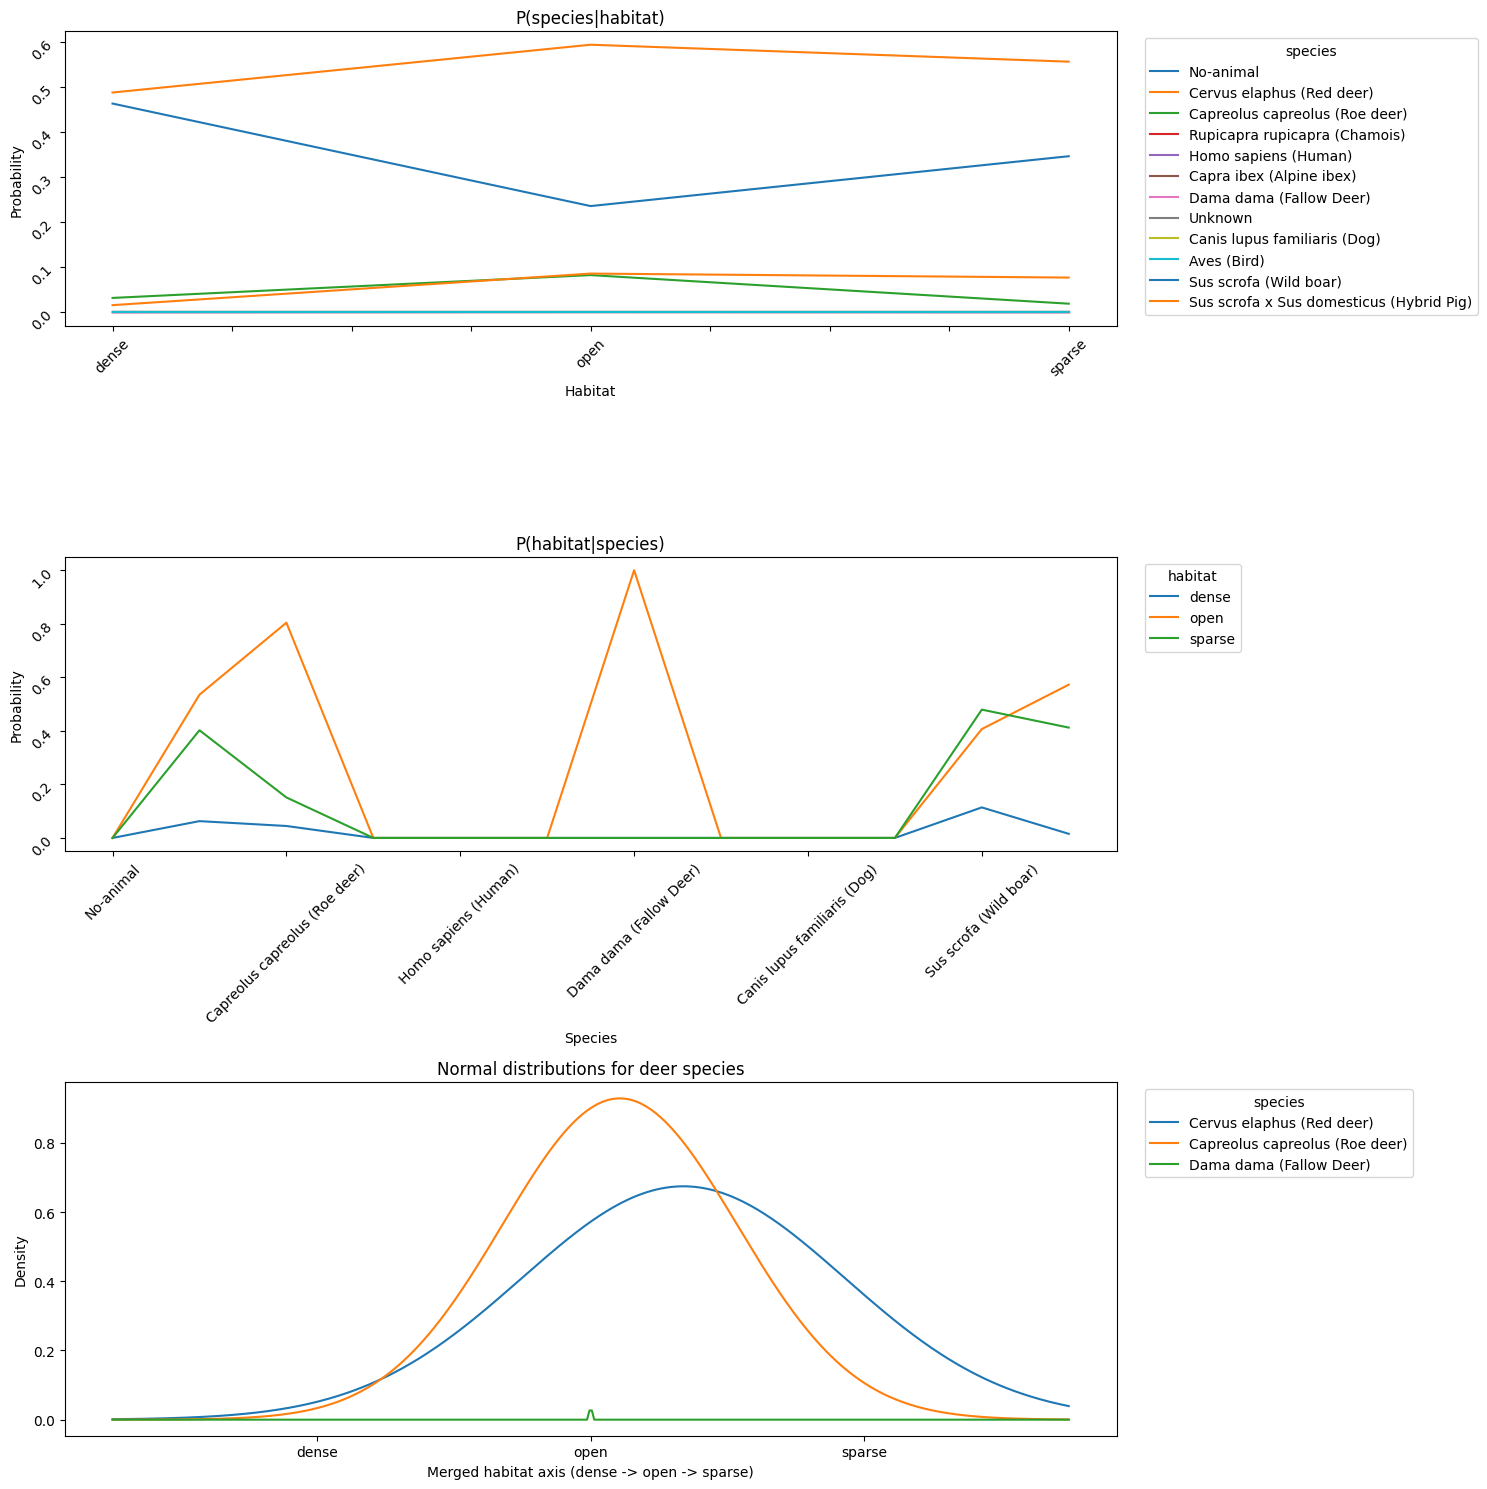

In [79]:
import numpy as np
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(15, 15), gridspec_kw={"height_ratios": [1, 1, 1.2]})

# P(species|habitat)
p_species_given_habitat.plot(ax=axs[0])
axs[0].set_title("P(species|habitat)")
axs[0].set_ylabel("Probability")
axs[0].set_xlabel("Habitat")
axs[0].tick_params(rotation=45)
axs[0].legend(title="species", bbox_to_anchor=(1.02, 1), loc="upper left")

# P(habitat|species)
p_habitat_given_species.plot(ax=axs[1])
axs[1].set_title("P(habitat|species)")
axs[1].set_ylabel("Probability")
axs[1].set_xlabel("Species")
axs[1].tick_params(rotation=45)
axs[1].legend(title="habitat", bbox_to_anchor=(1.02, 1), loc="upper left")

# Normal distributions for deer species across the merged habitat axis
deer_species = [
    "Cervus elaphus (Red deer)",
    "Capreolus capreolus (Roe deer)",
    "Rupicapra rupicapra (Chamois)",
    "Capra ibex (Alpine ibex)",
    "Dama dama (Fallow Deer)",
]
habitat_positions = np.arange(len(merged_habitats), dtype=float)
x = np.linspace(-0.75, len(merged_habitats) - 0.25, 400)
for species_name in deer_species:
    if species_name not in p_habitat_given_species.index:
        continue
    probabilities = p_habitat_given_species.loc[species_name].reindex(merged_habitats).to_numpy(dtype=float)
    total_probability = probabilities.sum()
    if total_probability <= 0:
        continue
    mean = float(np.dot(habitat_positions, probabilities))
    variance = float(np.dot((habitat_positions - mean) ** 2, probabilities))
    std = float(np.sqrt(max(variance, 1e-6)))
    pdf = (1.0 / (std * np.sqrt(2.0 * np.pi))) * np.exp(-0.5 * ((x - mean) / std) ** 2)
    axs[2].plot(x, pdf, label=species_name)
axs[2].set_title("Normal distributions for deer species")
axs[2].set_xlabel("Merged habitat axis (dense -> open -> sparse)")
axs[2].set_ylabel("Density")
axs[2].set_xticks(habitat_positions)
axs[2].set_xticklabels(merged_habitats)
axs[2].legend(title="species", bbox_to_anchor=(1.02, 1), loc="upper left")

fig.tight_layout()
plt.show()